<a href="https://colab.research.google.com/github/abhigyanpal1/MERN-assignments/blob/main/Brain_tumour_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf

# ─── GPU memory growth (safe to run even if TF is already initialized) ───
try:
    gpus = tf.config.list_physical_devices('GPU')
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    if gpus:
        print(f" Memory growth set on {len(gpus)} GPU(s).")
    else:
        print("ℹ No GPU found, running on CPU.")
except RuntimeError as e:
    # Happens if GPUs are already initialized — safe to ignore
    print(" Could not set memory growth:", e)


 Memory growth set on 1 GPU(s).


In [ ]:
!pip install matplotlib scikit-learn

In [3]:
import os, cv2, numpy as np
from tensorflow.keras.utils import to_categorical

def load_images_and_labels(path_no, path_yes, img_size=(224, 224)):
    images, labels = [], []
    for label, path in enumerate([path_no, path_yes]):
        for fname in os.listdir(path):
            img_path = os.path.join(path, fname)
            img = cv2.imread(img_path)
            img = cv2.resize(img, img_size)
            images.append(img / 255.0)
            labels.append(label)
    return np.array(images), np.array(labels)

# now you can load:
images, labels = load_images_and_labels(path_no, path_yes)
print(f"Loaded {images.shape[0]} images with shape {images.shape[1:]}")
labels = to_categorical(labels, num_classes=2)


Loaded 253 images with shape (224, 224, 3)


In [4]:
# Mount your Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Point to the “no” and “yes” folders in your Drive
# Change the path after MyDrive/... to match where you put them
path_no  = '/content/drive/MyDrive/no'
path_yes = '/content/drive/MyDrive/yes'

# Verify and print how many images are in each
import os
for label, p in [('no', path_no), ('yes', path_yes)]:
    if not os.path.isdir(p):
        raise FileNotFoundError(f"Folder for '{label}' not found: {p}")
    count = len([f for f in os.listdir(p) if os.path.isfile(os.path.join(p, f))])
    print(f"{count} images in folder '{label}': {p}")

# Now you can call your loader:
images, labels = load_images_and_labels(path_no, path_yes)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
98 images in folder 'no': /content/drive/MyDrive/no
155 images in folder 'yes': /content/drive/MyDrive/yes


In [ ]:
import tensorflow as tf

# ─── GPU memory growth (only if possible) ──────────────────────────────────
try:
    gpus = tf.config.list_physical_devices('GPU')
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    if gpus:
        print(f"Memory growth set on {len(gpus)} GPU(s).")
    else:
        print("No GPU found, running on CPU.")
except RuntimeError:
    # GPUs already initialized or not supported—ignore
    pass


✅ Memory growth set on 1 GPU(s).


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 555ms/step - accuracy: 0.9839 - loss: 0.5392 - val_accuracy: 0.8684 - val_loss: 0.8188 - learning_rate: 5.4151e-04
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 517ms/step - accuracy: 0.9834 - loss: 0.4668 - val_accuracy: 0.8816 - val_loss: 0.7465 - learning_rate: 5.4151e-04
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 657ms/step - accuracy: 0.9689 - loss: 0.4378 - val_accuracy: 0.8421 - val_loss: 0.7216 - learning_rate: 5.4151e-04
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 563ms/step - accuracy: 0.9644 - loss: 0.4186 - val_accuracy: 0.8026 - val_loss: 0.7040 - learning_rate: 5.4151e-04
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 514ms/step - accuracy: 0.9793 - loss: 0.3589 - val_accuracy: 0.8553 - val_loss: 0.6429 - learning_rate: 5.4151e-04
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 493ms/step - accuracy: 0.9946 - loss: 0.2967 - val_accuracy: 0.8158 - val_loss: 0.6801 - learning_rate: 5.4151e-04
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 647ms/step - accuracy: 0.9945 - loss:

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 662ms/step
Classification Report:
               precision    recall  f1-score   support

    NO Tumor       0.83      0.83      0.83        29
       Tumor       0.89      0.89      0.89        47

    accuracy                           0.87        76
   macro avg       0.86      0.86      0.86        76
weighted avg       0.87      0.87      0.87        76



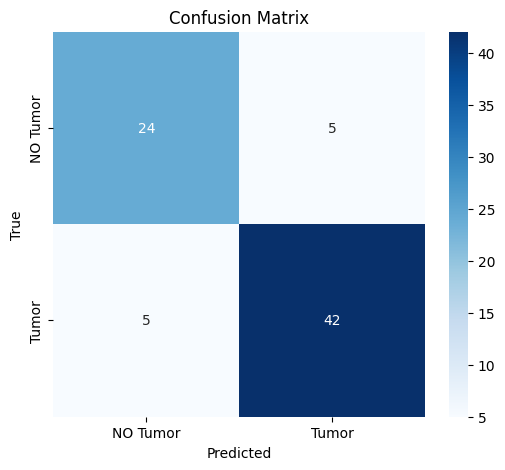

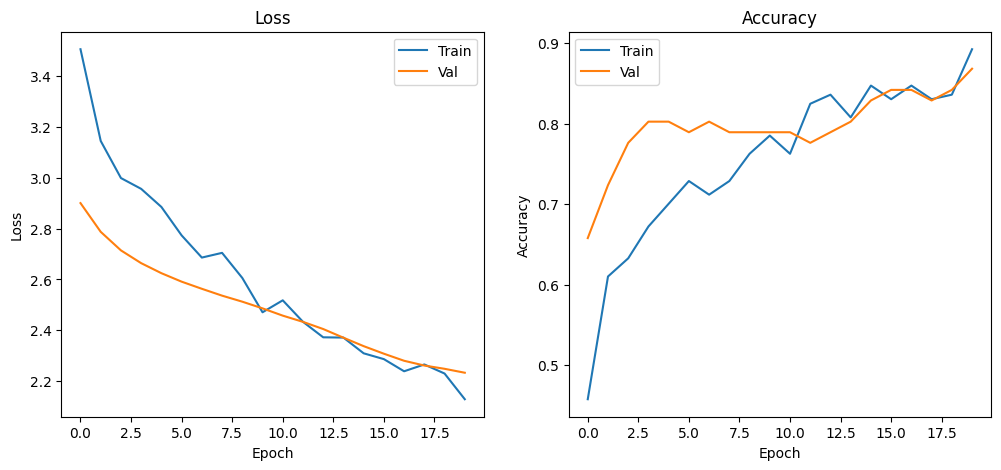

In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# 1) Imports & GPU setup
# ──────────────────────────────────────────────────────────────────────────────
import os, zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization, Activation
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Enable dynamic GPU memory growth



for label, p in [('no', path_no), ('yes', path_yes)]:
    if not os.path.isdir(p):
        raise FileNotFoundError(f"Folder for '{label}' not found: {p}")

# ──────────────────────────────────────────────────────────────────────────────
# 3) Load and preprocess images
# ──────────────────────────────────────────────────────────────────────────────
def load_images_and_labels(path_no, path_yes, img_size=(224, 224)):
    images, labels = [], []
    for label, path in enumerate([path_no, path_yes]):
        for fname in os.listdir(path):
            img = cv2.imread(os.path.join(path, fname))
            img = cv2.resize(img, img_size)
            images.append(img / 255.0)
            labels.append(label)
    return np.array(images), np.array(labels)

images, labels = load_images_and_labels(path_no, path_yes)
labels = to_categorical(labels, num_classes=2)

X_train, X_test, y_train, y_test = train_test_split(
    images, labels, test_size=0.3, stratify=labels, random_state=42
)
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

callbacks = [early_stop, reduce_lr]
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=30,
    validation_data=(X_test, y_test),
    callbacks=callbacks
)

datagen = ImageDataGenerator(
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    #shear_range=0.2,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# ──────────────────────────────────────────────────────────────────────────────
# 4) Whale Optimization Algorithm (WOA) with memory/compute safe settings
# ──────────────────────────────────────────────────────────────────────────────
def initialize_population(num_whales):
    # each whale has 3 params: [lr_raw, dropout_raw, neurons_raw]
    return np.random.rand(num_whales, 3)
def objective_function(params):
    # 1) Ensure params are in [0,1]
    lr_raw, dr_raw, neu_raw = np.clip(params, 0.0, 1.0)

    # ...then map to actual hyperparameters:
    learning_rate = 10**(lr_raw*(np.log10(1e-2)-np.log10(1e-6)) + np.log10(1e-6))
    dropout_rate  = float(tf.clip_by_value(dr_raw, 0.1, 0.8))
    neurons       = int(neu_raw * 512 + 64)

    # ...rest of your model build / fit / return val_loss...

def objective_function(params):
    # Clear previous model/graph
    K.clear_session()

    lr_raw, dr_raw, neu_raw = params
    # map raw values into actual hyperparameters
    learning_rate = 10**(lr_raw * (np.log10(1e-2) - np.log10(1e-6)) + np.log10(1e-6))
    dropout_rate  = float(tf.clip_by_value(dr_raw, 0.1, 0.8))
    neurons       = int(neu_raw * (512) + 64)  # scale [0,1]→[64,576]

    # build frozen base + small trainable head
    base = VGG19(weights='imagenet', include_top=False, input_shape=(224,224,3))
    for layer in base.layers:
        layer.trainable = False
    for layer in base.layers[-4:]:
        layer.trainable = True

    x = base.output
    x = Flatten()(x)
    x = Dense(neurons, kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(neurons//2, kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.3)(x)
    preds = Dense(2, activation='softmax')(x)

    model = Model(inputs=base.input, outputs=preds)
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

    # train only 2 epochs with small batch for fitness
    history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=30,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr]
    )
    return history.history['val_loss'][-1]

def update_positions(pop, best_pos, a, num_whales):
    for i in range(num_whales):
        r = np.random.rand()
        A = 2*a*r - a
        C = 2*np.random.rand()
        p = np.random.rand()
        if p < 0.5:
            if abs(A) >= 1:
                rand_whale = pop[np.random.randint(num_whales)]
                D = abs(C*rand_whale - pop[i])
                pop[i] = rand_whale - A*D
            else:
                D = abs(C*best_pos - pop[i])
                pop[i] = best_pos - A*D
        else:
            D = abs(best_pos - pop[i])
            pop[i] = D * np.exp(a*np.random.rand()) * np.cos(2*np.pi*np.random.rand())
    return pop

def whale_optimization_algorithm(num_whales, num_iterations):
    pop = initialize_population(num_whales)
    best_loss = float('inf')
    best_pos  = None

    for t in range(num_iterations):
        # Clamp every whale to [0,1] before evaluation
        pop = np.clip(pop, 0.0, 1.0)

        # Evaluate fitness
        losses = np.array([objective_function(p) for p in pop])
        idx    = np.argmin(losses)
        if losses[idx] < best_loss:
            best_loss = losses[idx]
            best_pos  = pop[idx].copy()

        # WOA position updates
        a = 2 - t * (2/num_iterations)
        pop = update_positions(pop, best_pos, a, num_whales)

    # Final clamp just in case
    return np.clip(best_pos, 0.0, 1.0)

# ──────────────────────────────────────────────────────────────────────────────
# 5) Run WOA & extract best hyperparameters
# ──────────────────────────────────────────────────────────────────────────────
num_whales, num_iterations = 3, 2
best_raw_params = whale_optimization_algorithm(num_whales, num_iterations)
lr_raw, dr_raw, neu_raw = best_raw_params
best_learning_rate = 10**(lr_raw * (np.log10(1e-2) - np.log10(1e-6)) + np.log10(1e-6))
best_dropout_rate  = float(tf.clip_by_value(dr_raw, 0.1, 0.8))
best_neurons       = int(neu_raw * (512) + 64)

# ──────────────────────────────────────────────────────────────────────────────
# 6) Build & train final model with optimized hyperparameters
# ──────────────────────────────────────────────────────────────────────────────
base = VGG19(weights='imagenet', include_top=False, input_shape=(224,224,3))
for layer in base.layers:
    layer.trainable = False

x = base.output
x = Flatten()(x)
x = Dense(best_neurons, kernel_regularizer=l2(0.01))(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(best_dropout_rate)(x)
x = Dense(best_neurons//2, kernel_regularizer=l2(0.01))(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(best_dropout_rate)(x)
preds = Dense(2, activation='softmax')(x)

model = Model(inputs=base.input, outputs=preds)
model.compile(
    optimizer=Adam(learning_rate=best_learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=20,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

# ──────────────────────────────────────────────────────────────────────────────
# 7) Evaluate & visualize
# ──────────────────────────────────────────────────────────────────────────────
y_pred       = model.predict(X_test)
y_pred_cls   = np.argmax(y_pred, axis=1)
y_true_cls   = np.argmax(y_test, axis=1)

print("Classification Report:\n",
      classification_report(y_true_cls, y_pred_cls,
                            target_names=['NO Tumor','Tumor']))

cm = confusion_matrix(y_true_cls, y_pred_cls)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NO Tumor','Tumor'],
            yticklabels=['NO Tumor','Tumor'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

def plot_learning_curves(hist):
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(hist.history['loss'],      label='Train')
    plt.plot(hist.history['val_loss'],  label='Val')
    plt.title('Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(hist.history['accuracy'],      label='Train')
    plt.plot(hist.history['val_accuracy'],  label='Val')
    plt.title('Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
    plt.show()

plot_learning_curves(history)
